#### Step - 1 Data Loading 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Loading data
train = pd.read_csv("./RawData/train_SCkXwSx_cNdUk28_icK39vy_36Oa6WQ.csv")
test = pd.read_csv("./RawData/test_opI5Wmb_N886n9d_eE68Ob0_dOXWldY.csv")

In [5]:
# Shapes
print("Train Shape:",train.shape)
print("Test Shape:",test.shape)

Train Shape: (89392, 12)
Test Shape: (59595, 11)


In [6]:
# 10 Sample of train data
train.sample(10)

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
10628,10629,Male,Urban,High School,More than 10L,1,7,3381,More than 1,A,Silver,99456
37686,37687,Female,Urban,High School,More than 10L,1,6,0,More than 1,B,Platinum,65496
69431,69432,Female,Urban,High School,5L-10L,1,8,2846,More than 1,C,Platinum,163920
72697,72698,Female,Urban,Bachelor,2L-5L,1,5,3823,More than 1,B,Silver,60840
26182,26183,Male,Urban,Bachelor,5L-10L,0,6,4234,More than 1,A,Platinum,417612
38065,38066,Male,Urban,High School,2L-5L,0,2,4399,1,A,Platinum,64104
75254,75255,Male,Urban,Bachelor,5L-10L,1,3,6574,More than 1,A,Platinum,64860
57803,57804,Female,Urban,High School,2L-5L,1,8,8226,More than 1,C,Silver,207768
32418,32419,Male,Urban,High School,More than 10L,1,2,6267,1,A,Gold,62028
11602,11603,Male,Urban,Bachelor,5L-10L,1,6,12310,More than 1,A,Platinum,102336


In [7]:
# Column Overview
print(train.columns.tolist())

['id', 'gender', 'area', 'qualification', 'income', 'marital_status', 'vintage', 'claim_amount', 'num_policies', 'policy', 'type_of_policy', 'cltv']


In [8]:
# Data types checking
train.dtypes

id                 int64
gender            object
area              object
qualification     object
income            object
marital_status     int64
vintage            int64
claim_amount       int64
num_policies      object
policy            object
type_of_policy    object
cltv               int64
dtype: object

In [9]:
# Basic Info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              89392 non-null  int64 
 1   gender          89392 non-null  object
 2   area            89392 non-null  object
 3   qualification   89392 non-null  object
 4   income          89392 non-null  object
 5   marital_status  89392 non-null  int64 
 6   vintage         89392 non-null  int64 
 7   claim_amount    89392 non-null  int64 
 8   num_policies    89392 non-null  object
 9   policy          89392 non-null  object
 10  type_of_policy  89392 non-null  object
 11  cltv            89392 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 8.2+ MB


In [10]:
for col in train.columns:
    print(f"{col}:")
    print(train[col].unique())

id:
[    1     2     3 ... 89390 89391 89392]
gender:
['Male' 'Female']
area:
['Urban' 'Rural']
qualification:
['Bachelor' 'High School' 'Others']
income:
['5L-10L' 'More than 10L' '2L-5L' '<=2L']
marital_status:
[1 0]
vintage:
[5 8 7 6 1 0 3 4 2]
claim_amount:
[ 5790  5080  2599 ... 15361 12911 17143]
num_policies:
['More than 1' '1']
policy:
['A' 'C' 'B']
type_of_policy:
['Platinum' 'Gold' 'Silver']
cltv:
[ 64308 515400  64212 ... 148116 123156 132864]


In [11]:
# Statistics Overview
train.describe()

,id,marital_status,vintage,claim_amount,cltv
count,89392.000000,89392.000000,89392.000000,89392.000000,89392.000000
mean,44696.500000,0.575488,4.595669,4351.502416,97952.828978
std,25805.391969,0.494272,2.290446,3262.359775,90613.814793
min,1.000000,0.000000,0.000000,0.000000,24828.000000
25%,22348.750000,0.000000,3.000000,2406.000000,52836.000000
50%,44696.500000,1.000000,5.000000,4089.000000,66396.000000
75%,67044.250000,1.000000,6.000000,6094.000000,103440.000000
max,89392.000000,1.000000,8.000000,31894.000000,724068.000000


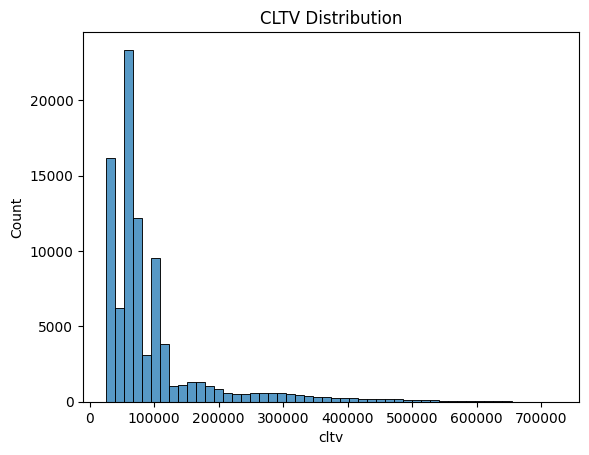

In [12]:
# Target Distribution 
sns.histplot(train['cltv'], bins=50)
plt.title("CLTV Distribution")
plt.show()

In [13]:
train['cltv'] = np.log1p(train['cltv'])

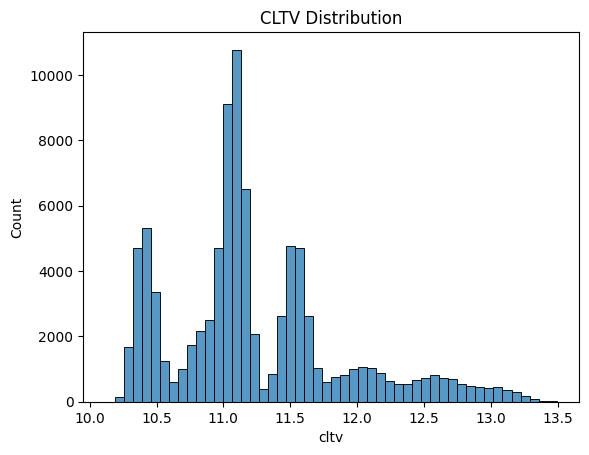

In [14]:
# Target Distribution 
sns.histplot(train['cltv'], bins=50)
plt.title("CLTV Distribution")
plt.show()

#### Step 2 - Data Cleaning

In [15]:
# creating copies of train and test
train_df = train.copy()
test_df = test.copy()

In [16]:
# Dropping ID column from test and train and storing the test ids for prediction use
test_ids = test_df['id']


train_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [17]:
# Converting income from ORDINAL to NUMERIC by giving a midpoint range
income_map = {
    '<=2L': 1.5,
    '2L-5L': 3.5,
    '5L-10L': 7.5,
    'More than 10L': 12
}

# cleaning the income
train_df['income'] = train_df['income'].str.strip()
test_df['income'] = test_df['income'].str.strip()

train_df['income'] = train_df['income'].map(income_map)
test_df['income'] = test_df['income'].map(income_map)

In [18]:
# Converting the num_policies column
policy_map = {
    '1': 1,
    'More than 1': 2
}

train_df['num_policies'] = train_df['num_policies'].map(policy_map)
test_df['num_policies'] = test_df['num_policies'].map(policy_map)

In [19]:
# Encoding manually the gender and area because of only 2 categories
train_df['gender'] = train_df['gender'].map({'Male': 1, 'Female': 0})
test_df['gender'] = test_df['gender'].map({'Male': 1, 'Female': 0})

train_df['area'] = train_df['area'].map({'Urban': 1, 'Rural': 0})
test_df['area'] = test_df['area'].map({'Urban': 1, 'Rural': 0})

In [20]:
train_df.sample(10)

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
25013,1,1,Others,7.5,0,4,6018,2,A,Platinum,11.044792
26750,1,1,High School,7.5,1,8,3694,2,A,Platinum,10.866299
87710,1,1,Bachelor,3.5,1,4,6227,2,A,Gold,11.914710
20486,1,1,Bachelor,7.5,0,5,8315,2,C,Gold,10.928471
55515,1,1,High School,7.5,0,2,4205,2,B,Silver,11.035744
32882,0,1,Bachelor,7.5,1,5,3759,2,B,Gold,11.484413
2987,0,1,Bachelor,12.0,1,6,4095,2,A,Platinum,11.542455
36379,1,1,Bachelor,7.5,1,7,6773,2,A,Silver,12.641488
43395,1,1,Bachelor,3.5,0,7,7188,2,B,Platinum,11.588339
11226,1,1,Bachelor,7.5,1,6,2238,1,A,Platinum,10.555526


In [21]:
test_df.sample(10)

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
31714,1,1,High School,7.5,1,8,3048,1,A,Platinum
50084,1,1,High School,7.5,1,7,0,1,A,Platinum
58528,0,1,High School,7.5,1,0,8317,2,B,Gold
16769,1,1,High School,7.5,0,5,8439,1,C,Platinum
31514,1,0,Others,12.0,0,6,2140,1,A,Silver
44823,0,0,High School,3.5,0,1,9645,1,A,Silver
24943,1,1,High School,7.5,1,0,2156,2,A,Gold
5891,0,1,Bachelor,3.5,0,6,2164,1,B,Silver
49710,1,1,High School,7.5,1,4,4888,2,B,Silver
54955,1,0,Bachelor,7.5,1,4,0,2,A,Platinum


In [22]:
# Checking missing Values
print("Train Missing:\n", train_df.isnull().sum())
print("\nTest Missing:\n", test_df.isnull().sum())

Train Missing:
 gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

Test Missing:
 gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
dtype: int64


In [23]:
# chekcing dtypes
print(train_df.dtypes)

gender              int64
area                int64
qualification      object
income            float64
marital_status      int64
vintage             int64
claim_amount        int64
num_policies        int64
policy             object
type_of_policy     object
cltv              float64
dtype: object


#### Step - 3 Exploratory Data Analysis 

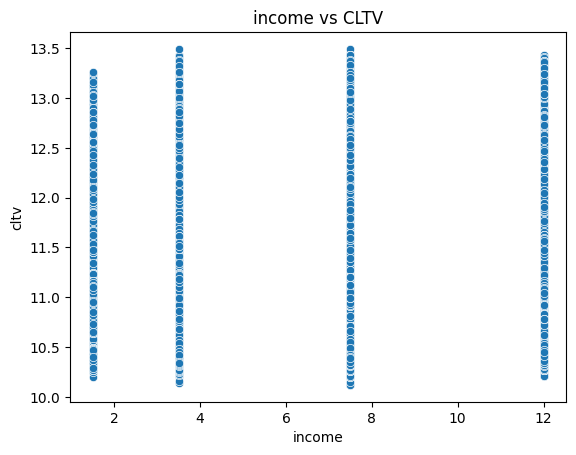

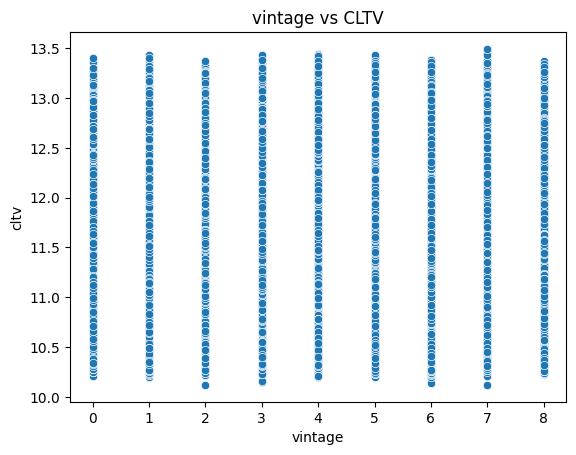

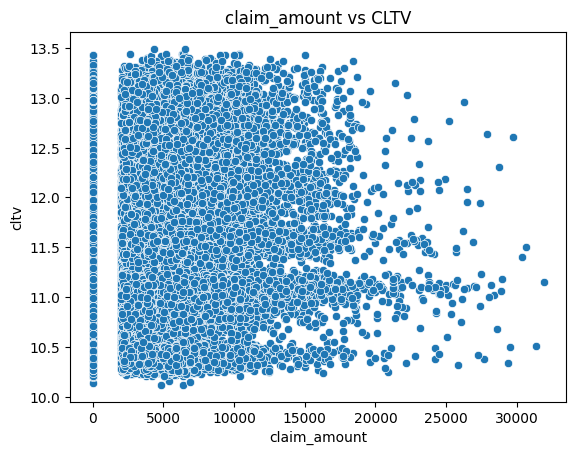

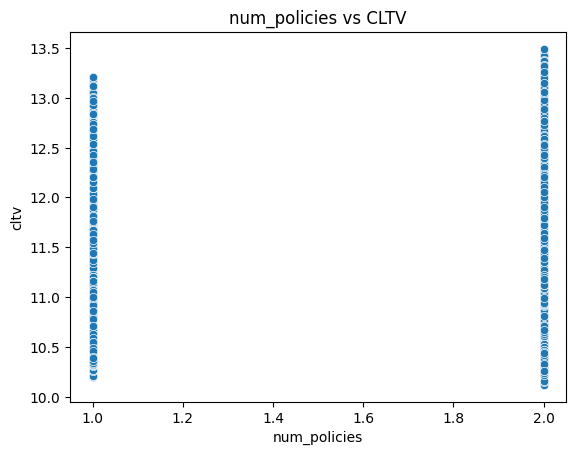

In [24]:
# Numerical Vs Target
num_cols = ['income', 'vintage', 'claim_amount', 'num_policies']

for col in num_cols:
    sns.scatterplot(x=train_df[col], y=train_df['cltv'])
    plt.title(f"{col} vs CLTV")
    plt.show()

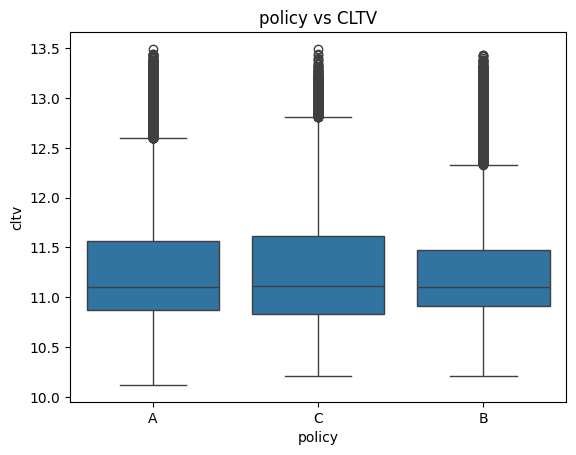

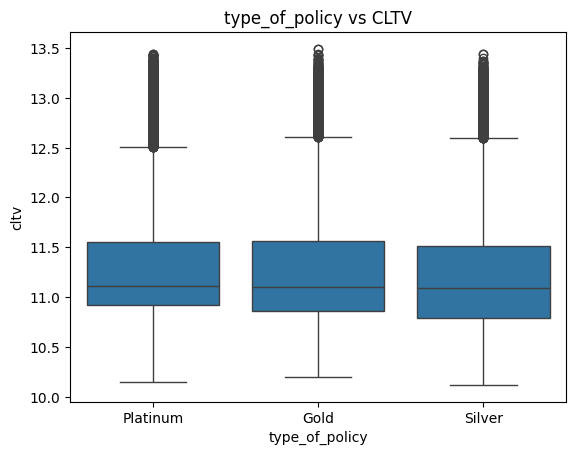

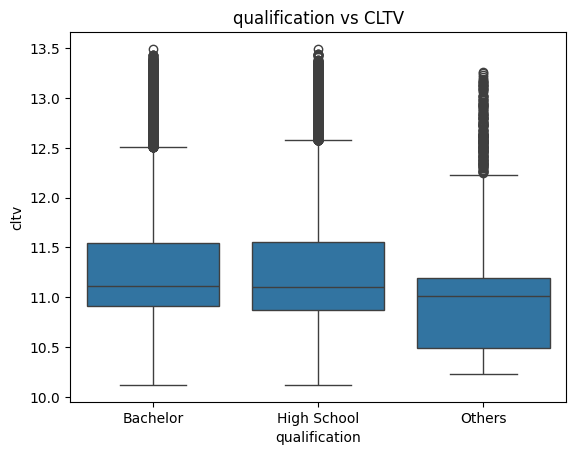

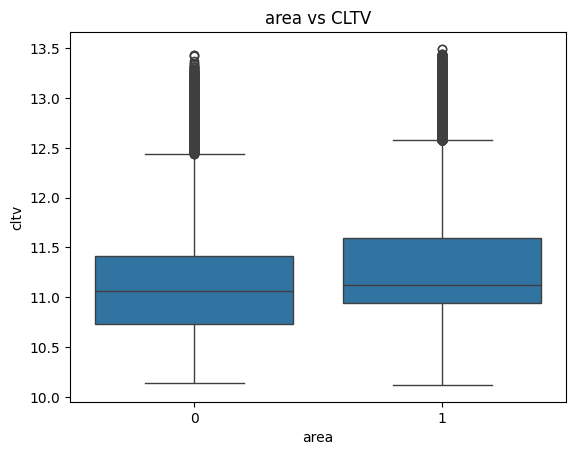

In [25]:
# Categorical VS Target
cat_cols = ['policy', 'type_of_policy', 'qualification', 'area']

for col in cat_cols:
    sns.boxplot(x=train_df[col], y=train_df['cltv'])
    plt.title(f"{col} vs CLTV")
    plt.show()

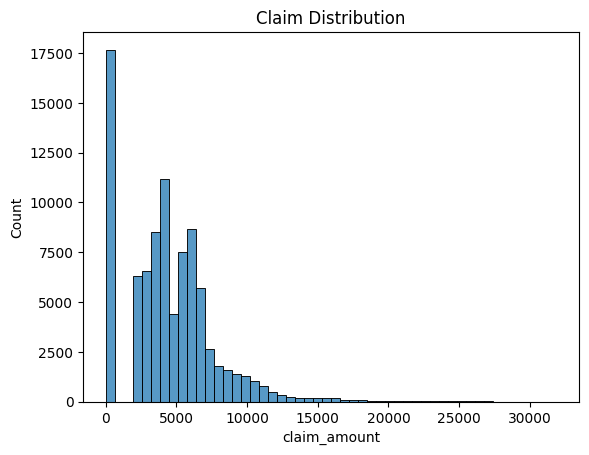

In [26]:
sns.histplot(train_df['claim_amount'], bins=50)
plt.title("Claim Distribution")
plt.show()

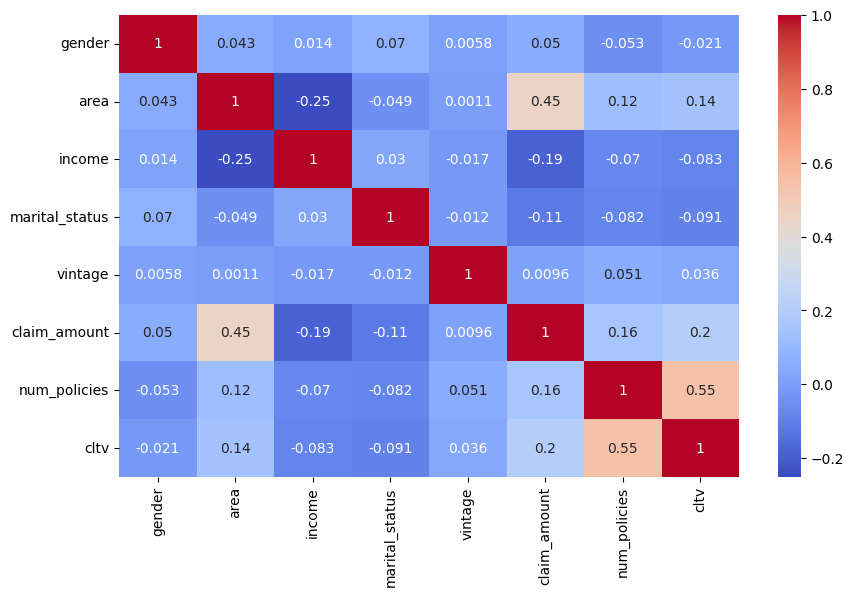

In [27]:
corr = train_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [28]:
# Statistical Testing 
# Anova
from scipy.stats import f_oneway

cat_cols = ['area', 'qualification', 'policy', 'type_of_policy']

for col in cat_cols:
    groups = [train_df[train_df[col] == val]['cltv'] for val in train_df[col].unique()]
    f_stat, p_val = f_oneway(*groups)
    print(f"{col} -> p-value: {p_val}")

area -> p-value: 0.0
qualification -> p-value: 4.666209941811979e-85
policy -> p-value: 2.925086546753265e-47
type_of_policy -> p-value: 1.8950539334477988e-39


In [29]:
# Anova For Income
groups = [train_df[train_df['income'] == val]['cltv'] for val in train_df['income'].unique()]
f_stat, p_val = f_oneway(*groups)

print("income → p-value:", p_val)

income → p-value: 9.147601447469604e-158


ANOVA Analysis
- Area(0.0) -> Very strong effect

- Qualification(4.66e-85) -> Extremely Strong predictor

- Policy(2.92e-47) -> directly impacts CLTV

- type_of_policy(1.89e-39) -> strong effect 

Correlation
- num_policies ->  (strongest correlation)

- claim_amount ->  (weak positive)

- income -> (weak)

EDA Plot Analysis
- CLTV displays strong non-linear behavior with respect to numerical features, while categorical features like policy, type_of_policy, and qualification show clear segmentation effects on CLTV.
- The claim_amount variable is highly skewed with a high frequency of zero claims, indicating different risk groups of customers that need to be considered for effective feature engineering.
- Features like num_policies and area show clear effects on CLTV, indicating that customer engagement and segmentation effects on demographics are key influencers for CLTV.

#### Step - 4 Feature engineering

In [30]:
train_fe = train_df.copy()
test_fe = test_df.copy()

In [31]:
# Log Transform
for df in [train_fe, test_fe]:
    df['log_claim'] = np.log1p(df['claim_amount'])
    df['log_vintage'] = np.log1p(df['vintage'])
    df['log_income'] = np.log1p(df['income'])

    df['zero_claim'] = (df['claim_amount'] == 0).astype(int)
    df['claim_flag'] = (df['claim_amount'] > 0).astype(int)

In [32]:
# High Value Features
for df in [train_fe, test_fe]:
    
    df['customer_intensity'] = df['num_policies'] * df['vintage']
    
    df['policies_per_year'] = df['num_policies'] / (df['vintage'] + 1)
    
    df['engagement_score'] = df['num_policies'] * 2 + df['vintage']

In [33]:
def target_encode_smooth(train, test, col, target, alpha=15):
    
    global_mean = train[target].mean()
    
    stats = train.groupby(col)[target].agg(['mean', 'count'])
    
    smooth = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)
    
    train_encoded = train[col].map(smooth)
    test_encoded = test[col].map(smooth)
    
    train_encoded.fillna(global_mean, inplace=True)
    test_encoded.fillna(global_mean, inplace=True)
    
    return train_encoded, test_encoded

In [34]:
# Encoing Categorical Values
cat_cols = ['policy', 'type_of_policy', 'qualification']

for col in cat_cols:
    train_fe[col + '_te'], test_fe[col + '_te'] = target_encode_smooth(
        train_fe, test_fe, col, 'cltv'
    )

In [43]:
import warnings
warnings.filterwarnings('ignore')
for col in ['policy', 'type_of_policy']:
    
    freq_map = train_fe[col].value_counts()
    
    train_fe[col + '_freq'] = train_fe[col].map(freq_map)
    test_fe[col + '_freq'] = test_fe[col].map(freq_map)

    train_fe[col + '_freq'].fillna(0, inplace=True)
    test_fe[col + '_freq'].fillna(0, inplace=True)

In [44]:
# Droping raw Catergoricals
train_fe.drop(columns=['policy', 'type_of_policy', 'qualification'], inplace=True)
test_fe.drop(columns=['policy', 'type_of_policy', 'qualification'], inplace=True)

In [45]:
# Dropping weak Feature
train_fe.drop(columns=['gender'], inplace=True)
test_fe.drop(columns=['gender'], inplace=True)

In [46]:
train_fe.sample(10)

,area,income,marital_status,vintage,claim_amount,num_policies,cltv,log_claim,log_vintage,log_income,zero_claim,claim_flag,customer_intensity,policies_per_year,engagement_score,policy_te,type_of_policy_te,qualification_te,policy_freq,type_of_policy_freq
59243,1,12.0,1,5,4403,2,11.492039,8.390268,1.791759,2.564949,0,1,10,0.333333,9,11.252568,11.245404,11.246855,56644,20586
8518,1,7.5,1,3,5048,1,10.370267,8.526945,1.386294,2.140066,0,1,3,0.250000,5,11.252568,11.256631,11.245839,56644,47796
28981,0,7.5,1,6,3060,1,10.959836,8.026497,1.945910,2.140066,0,1,6,0.142857,8,11.252568,11.245404,11.033308,56644,20586
72726,1,1.5,1,2,9390,2,11.897378,9.147507,1.098612,0.916291,0,1,4,0.666667,6,11.252568,11.256631,11.246855,56644,47796
41188,1,3.5,1,5,4569,1,10.433321,8.427268,1.791759,1.504077,0,1,5,0.166667,7,11.252568,11.245404,11.245839,56644,20586
42307,1,3.5,0,6,3509,2,13.382314,8.163371,1.945910,1.504077,0,1,12,0.285714,10,11.252568,11.256631,11.245839,56644,47796
38598,1,7.5,1,4,2784,1,11.112224,7.932003,1.609438,2.140066,0,1,4,0.200000,6,11.187571,11.256631,11.245839,24635,47796
38921,1,12.0,0,4,5652,1,10.826098,8.639942,1.609438,2.564949,0,1,4,0.200000,6,11.252568,11.256631,11.245839,56644,47796
85308,0,7.5,1,6,2628,2,11.542805,7.874359,1.945910,2.140066,0,1,12,0.285714,10,11.252568,11.256631,11.246855,56644,47796
78001,0,7.5,0,6,0,1,10.804888,0.000000,1.945910,2.140066,1,0,6,0.142857,8,11.252568,11.245404,11.246855,56644,20586


In [47]:
test_fe.sample(10)

,area,income,marital_status,vintage,claim_amount,num_policies,log_claim,log_vintage,log_income,zero_claim,claim_flag,customer_intensity,policies_per_year,engagement_score,policy_te,type_of_policy_te,qualification_te,policy_freq,type_of_policy_freq
54343,0,3.5,1,4,2917,2,7.978654,1.609438,1.504077,0,1,8,0.400000,8,11.252568,11.185610,11.245839,56644,21010
8880,1,7.5,1,7,7246,2,8.888343,2.079442,2.140066,0,1,14,0.250000,11,11.282224,11.256631,11.245839,8113,47796
37309,0,7.5,1,8,0,1,0.000000,2.197225,2.140066,1,0,8,0.111111,10,11.252568,11.185610,11.245839,56644,21010
19341,0,7.5,0,3,2899,1,7.972466,1.386294,2.140066,0,1,3,0.250000,5,11.252568,11.256631,11.245839,56644,47796
2659,0,7.5,1,1,5938,2,8.689296,0.693147,2.140066,0,1,2,1.000000,5,11.252568,11.185610,11.245839,56644,21010
49765,0,7.5,0,3,0,2,0.000000,1.386294,2.140066,1,0,6,0.500000,7,11.252568,11.256631,11.245839,56644,47796
59500,1,7.5,1,1,6537,1,8.785387,0.693147,2.140066,0,1,1,0.500000,3,11.252568,11.245404,11.245839,56644,20586
32645,0,12.0,1,0,0,2,0.000000,0.000000,2.564949,1,0,0,2.000000,4,11.252568,11.245404,11.245839,56644,20586
5759,1,7.5,1,8,3615,1,8.193124,2.197225,2.140066,0,1,8,0.111111,10,11.252568,11.256631,11.245839,56644,47796
22023,1,3.5,0,6,0,2,0.000000,1.945910,1.504077,1,0,12,0.285714,10,11.252568,11.245404,11.246855,56644,20586


In [48]:
# chekcing the dtypes
train_fe.dtypes

area                     int64
income                 float64
marital_status           int64
vintage                  int64
claim_amount             int64
num_policies             int64
cltv                   float64
log_claim              float64
log_vintage            float64
log_income             float64
zero_claim               int64
claim_flag               int64
customer_intensity       int64
policies_per_year      float64
engagement_score         int64
policy_te              float64
type_of_policy_te      float64
qualification_te       float64
policy_freq              int64
type_of_policy_freq      int64
dtype: object

In [49]:
test_fe.dtypes

area                     int64
income                 float64
marital_status           int64
vintage                  int64
claim_amount             int64
num_policies             int64
log_claim              float64
log_vintage            float64
log_income             float64
zero_claim               int64
claim_flag               int64
customer_intensity       int64
policies_per_year      float64
engagement_score         int64
policy_te              float64
type_of_policy_te      float64
qualification_te       float64
policy_freq              int64
type_of_policy_freq      int64
dtype: object

In [50]:
train_fe.isnull().sum()

area                   0
income                 0
marital_status         0
vintage                0
claim_amount           0
num_policies           0
cltv                   0
log_claim              0
log_vintage            0
log_income             0
zero_claim             0
claim_flag             0
customer_intensity     0
policies_per_year      0
engagement_score       0
policy_te              0
type_of_policy_te      0
qualification_te       0
policy_freq            0
type_of_policy_freq    0
dtype: int64

In [51]:
test_fe.isnull().sum()

area                   0
income                 0
marital_status         0
vintage                0
claim_amount           0
num_policies           0
log_claim              0
log_vintage            0
log_income             0
zero_claim             0
claim_flag             0
customer_intensity     0
policies_per_year      0
engagement_score       0
policy_te              0
type_of_policy_te      0
qualification_te       0
policy_freq            0
type_of_policy_freq    0
dtype: int64

#### Step - 5 Model Building

In [52]:
# Splitting the data
X = train_fe.drop(columns=['cltv'])
y = train_fe['cltv']

X_test = test_fe.copy()

In [53]:
# Data Alignment 
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

In [54]:
# Checking the shapes 
print(X.shape)
print(y.shape)
print(X_test.shape)

(89392, 19)
(89392,)
(59595, 19)


In [57]:
# Importing the Libraries
import lightgbm as lgb
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

In [58]:
# Kfold setup
kf = KFold(n_splits=5, shuffle=True, random_state=18)

In [67]:
lgb_params = {
    'objective': 'regression',
    'learning_rate': 0.03,
    'num_leaves': 50,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 18
}

In [86]:
lgb_scores = []
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    
    print(f"\nFold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_model = lgb.LGBMRegressor(**lgb_params, n_estimators=2000)
    
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    
    preds = lgb_model.predict(X_val)
    score = r2_score(y_val, preds)
    
    print("R2 Score:", score)
    
    lgb_scores.append(score)
    
    # Test prediction
    test_preds += lgb_model.predict(X_test) / 5


Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 609
[LightGBM] [Info] Number of data points in the train set: 71513, number of used features: 19
[LightGBM] [Info] Start training from score 11.237042
R2 Score: 0.3216371583138563

Fold 2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012854 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 609
[LightGBM] [Info] Number of data points in the train set: 71513, number of used features: 19
[LightGBM] [Info] Start training from score 11.238939
R2 Score: 0.3261653291653851

Fold 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGB

In [70]:
print("\nFinal CV Score:", np.mean(lgb_scores))


Final CV Score: 0.3236140561817814


In [71]:
from xgboost import XGBRegressor
xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 18
}

In [87]:
xgb_scores = []
xgb_test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_model = XGBRegressor(**xgb_params)
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = xgb_model.predict(X_val)
    score = r2_score(y_val, preds)
    
    print(f"Fold {fold+1} XGB R2:", score)
    
    xgb_scores.append(score)
    xgb_test_preds += xgb_model.predict(X_test) / 5

print("\nXGBoost CV Score:", np.mean(xgb_scores))

Fold 1 XGB R2: 0.29585426694487194
Fold 2 XGB R2: 0.29717159104137836
Fold 3 XGB R2: 0.29541354174936496
Fold 4 XGB R2: 0.2962653894079579
Fold 5 XGB R2: 0.29622926735999733

XGBoost CV Score: 0.2961868113007141


#### The LightBGM Got higher RMSE than XGBoost

In [73]:
test_preds_final = np.expm1(test_preds)

In [90]:
submission = pd.DataFrame({
    'id': test_ids,
    'cltv': test_preds_final
})

submission.to_csv("submission.csv", index=False, float_format="%.2f")

In [74]:
print(lgb_scores)

[0.3216371583138563, 0.3261653291653851, 0.32424815153210107, 0.3220648324669668, 0.32395480943059773]


In [75]:
print(xgb_scores)

[0.29585426694487194, 0.29717159104137836, 0.29541354174936496, 0.2962653894079579, 0.29622926735999733]


In [88]:
import joblib
joblib.dump(lgb_model, "lgb_model.pkl")

['lgb_model.pkl']

In [89]:
train_fe.to_csv("./CleanedData/train_cleaned.csv", index=False)
test_fe.to_csv("./CleanedData/test_cleaned.csv", index=False)

In [97]:
import pandas as pd
sub = pd.read_csv("submission.csv")

In [98]:
print(sub.shape)
print(sub.head())
print(sub.isnull().sum())

(59595, 2)
      id       cltv
0  89393   79926.11
1  89394  105134.81
2  89395   81495.52
3  89396   77358.14
4  89397  106617.65
id      0
cltv    0
dtype: int64
